In [1]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.9/206.9 kB 16.8 MB/s eta 0:00:0

In [2]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [3]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

In [4]:
# Get all sessions (the first 100 of them)
all_sessions = one.search()[:100]
print(f"Scanned session count: {len(all_sessions)}")

sessions_with_spikes = []
for i, eid in enumerate(all_sessions):
    try:
        datasets = one.list_datasets(eid)
        if any('spikes.times' in d for d in datasets):
            sessions_with_spikes.append(eid)
            print(f"✓ {i+1}/{len(all_sessions)}: {eid} - Spike data EXISTS")
            if len(sessions_with_spikes) >= 5:  # Stop when the first 5 are found
                break
    except:
        pass

print(f"\nTotal {len(sessions_with_spikes)} sessions found")

Scanned session count: 100
✓ 32/100: ebce500b-c530-47de-8cb1-963c552703ea - Spike data EXISTS
✓ 88/100: a7eba2cf-427f-4df9-879b-e53e962eae18 - Spike data EXISTS
✓ 91/100: 5ae68c54-2897-4d3a-8120-426150704385 - Spike data EXISTS
✓ 92/100: 3a3ea015-b5f4-4e8b-b189-9364d1fc7435 - Spike data EXISTS

Total 4 sessions found


In [5]:
# =============================================================================
# DATA LOADING: Session and Spike Data
# =============================================================================

import numpy as np
from scipy import signal

print("="*70)
print("DATA LOADING")
print("="*70)

# Select the first session
eid = sessions_with_spikes[0]
print(f"\nSelected session: {eid}")

# Which spike files exist in this session?
datasets = one.list_datasets(eid)
spike_files = [d for d in datasets if 'spikes.times' in d]

print(f"\nAvailable spike files: {len(spike_files)}")
for f in spike_files[:3]:  # Show the first 3
    print(f"  {f}")

# Select the Collection (the most recent one)
if spike_files:
    collection = spike_files[-1].replace('/spikes.times.npy', '')
    print(f"\nSelected collection: {collection}")

    # LOAD DATA
    print("\nLoading data...")
    spikes_times = one.load_dataset(eid, 'spikes.times', collection=collection)
    spikes_clusters = one.load_dataset(eid, 'spikes.clusters', collection=collection)

    print(f"\n✓ Data loaded!")
    print(f"  Total spike count: {len(spikes_times):,}")

    # Unique neurons
    unique_neurons = np.unique(spikes_clusters)
    print(f"  Total neuron count: {len(unique_neurons)}")

    # Load trials
    trials = one.load_object(eid, 'trials')
    print(f"  Total trial count: {len(trials['intervals'])}")

    # Trial start times
    trial_starts = trials['intervals'][:, 0]

else:
    print("Spike file not found!")

DATA LOADING

Selected session: ebce500b-c530-47de-8cb1-963c552703ea

Available spike files: 3
  alf/probe00/pykilosort/#2024-03-22#/spikes.times.npy
  alf/probe00/pykilosort/#2024-05-06#/spikes.times.npy
  alf/probe00/pykilosort/spikes.times.npy

Selected collection: alf/probe00/pykilosort

Loading data...


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.times.npy: 100%|██████████| 647M/647M [00:11<00:00, 57.4MB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/spikes.clusters.npy: 100%|██████████| 323M/323M [00:05<00:00, 60.6MB/s]



✓ Data loaded!
  Total spike count: 80,867,860
  Total neuron count: 1557


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.goCueTrigger_times.npy: 100%|██████████| 4.68k/4.68k [00:00<00:00, 11.4kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.table.pqt: 100%|██████████| 47.7k/47.7k [00:00<00:00, 74.6kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/_ibl_trials.stimOff_times.npy: 100%|██████████| 4.68k/4.68k [00:00<00:00, 10.6kB/s]

  Total trial count: 569


In [6]:
# =============================================================================
# QUALITY CONTROL
# =============================================================================

print("\n" + "="*70)
print("QUALITY CONTROL")
print("="*70)

# Spike count for each neuron
neuron_spike_counts = []
for neuron_id in unique_neurons:
    neuron_spikes = spikes_times[spikes_clusters == neuron_id]
    neuron_spike_counts.append(len(neuron_spikes))

neuron_spike_counts = np.array(neuron_spike_counts)

print(f"\nNeuron statistics:")
print(f"  Min spikes: {neuron_spike_counts.min():,}")
print(f"  Max spikes: {neuron_spike_counts.max():,}")
print(f"  Mean: {neuron_spike_counts.mean():.1f}")
print(f"  Median: {np.median(neuron_spike_counts):.1f}")

# Filter good neurons (≥1000 spikes)
good_neurons = unique_neurons[neuron_spike_counts >= 1000]
print(f"\n✓ {len(good_neurons)} good neurons found (≥1000 spikes)")
print(f"  {100*len(good_neurons)/len(unique_neurons):.1f}% of total neurons")


QUALITY CONTROL

Neuron statistics:
  Min spikes: 1
  Max spikes: 1,004,807
  Mean: 51938.3
  Median: 25203.0

✓ 1319 good neurons found (≥1000 spikes)
  84.7% of total neurons


In [7]:
# =============================================================================
# SINGLE NEURON TAU CALCULATION (Test)
# =============================================================================

print("\n" + "="*70)
print("TAU CALCULATION - SINGLE NEURON TEST")
print("="*70)

# Select one of the good neurons
neuron_id = good_neurons[0]
neuron_spikes = spikes_times[spikes_clusters == neuron_id]

print(f"\nTest neuron: {neuron_id}")
print(f"Total spikes: {len(neuron_spikes):,}")

# Collect baseline spikes
baseline_spikes = []
for t_start in trial_starts[:200]:  # First 200 trials
    spikes_in_baseline = neuron_spikes[
        (neuron_spikes >= t_start - 1.5) &
        (neuron_spikes < t_start - 0.5)
    ]
    if len(spikes_in_baseline) > 0:
        baseline_spikes.append(spikes_in_baseline - (t_start - 1.5))

if len(baseline_spikes) > 0:
    all_baseline = np.concatenate(baseline_spikes)
    print(f"Baseline spike count: {len(all_baseline):,}")
    print(f"Number of trials with baseline: {len(baseline_spikes)}")

    # Spike count in 20ms bins
    bin_size = 0.020
    max_time = 1.0
    bins = np.arange(0, max_time, bin_size)

    # Spike count for each trial
    spike_counts_per_trial = []
    for baseline_trial in baseline_spikes:
        counts, _ = np.histogram(baseline_trial, bins=bins)
        spike_counts_per_trial.append(counts)

    spike_counts_per_trial = np.array(spike_counts_per_trial)
    mean_spike_count = spike_counts_per_trial.mean(axis=0)

    print(f"Spike count matrix: {spike_counts_per_trial.shape}")
    print(f"Average firing rate: {spike_counts_per_trial.mean() / bin_size:.2f} Hz")

    # Autocorrelation
    from scipy.signal import correlate

    autocorr = correlate(
        mean_spike_count - mean_spike_count.mean(),
        mean_spike_count - mean_spike_count.mean(),
        mode='full', method='auto'
    )
    autocorr = autocorr[len(autocorr)//2:]

    if autocorr[0] > 0:
        autocorr = autocorr / autocorr[0]

        # Calculate Tau
        tau_threshold = 1/np.e
        tau_bins = np.where(autocorr < tau_threshold)[0]

        if len(tau_bins) > 0:
            tau_ms = tau_bins[0] * bin_size * 1000
            print(f"\n TAU: {tau_ms:.1f} ms")

            if tau_ms < 100:
                print("  → FAST neuron (sensory)")
            elif tau_ms < 300:
                print("  → MEDIUM speed neuron")
            else:
                print("  → SLOW neuron (integrative)")
        else:
            print("\n Tau is too long (>1000ms)")
    else:
        print("\n Autocorrelation could not be calculated")
else:
    print("\n No baseline spikes in this neuron!")

print("\n Test successful! Now it can be calculated for all neurons.")


TAU CALCULATION - SINGLE NEURON TEST

Test neuron: 0
Total spikes: 42,899
Baseline spike count: 47
Number of trials with baseline: 35
Spike count matrix: (35, 49)
Average firing rate: 1.37 Hz

 TAU: 20.0 ms
  → FAST neuron (sensory)

 Test successful! Now it can be calculated for all neurons.



BATCH ANALYSIS: Calculating Tau for All Quality Neurons
Total number of neurons to analyze: 1319
Process starting...

  50/1319 processed... (Valid Tau found: 47)
  100/1319 processed... (Valid Tau found: 97)
  150/1319 processed... (Valid Tau found: 147)
  200/1319 processed... (Valid Tau found: 197)
  250/1319 processed... (Valid Tau found: 247)
  300/1319 processed... (Valid Tau found: 297)
  350/1319 processed... (Valid Tau found: 347)
  400/1319 processed... (Valid Tau found: 395)
  450/1319 processed... (Valid Tau found: 439)
  500/1319 processed... (Valid Tau found: 489)
  550/1319 processed... (Valid Tau found: 537)
  600/1319 processed... (Valid Tau found: 583)
  650/1319 processed... (Valid Tau found: 631)
  700/1319 processed... (Valid Tau found: 678)
  750/1319 processed... (Valid Tau found: 728)
  800/1319 processed... (Valid Tau found: 774)
  850/1319 processed... (Valid Tau found: 823)
  900/1319 processed... (Valid Tau found: 869)
  950/1319 processed... (Valid Tau fou

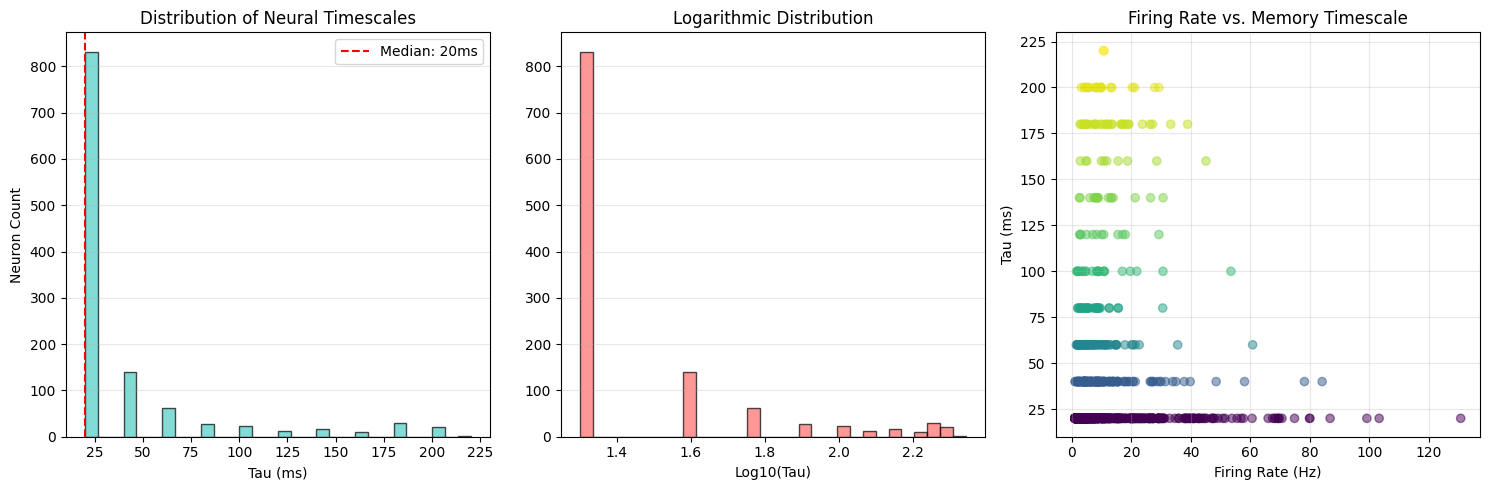

In [8]:
# =============================================================================
# CALCULATING TAU FOR ALL QUALITY NEURONS
# =============================================================================

import time
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("BATCH ANALYSIS: Calculating Tau for All Quality Neurons")
print("="*70)

# Lists to store results
tau_values = []
neuron_ids_with_tau = []
firing_rates = []

# Analysis parameters
bin_size = 0.020  # 20ms
max_time = 1.0    # 1 second baseline
bins = np.arange(0, max_time, bin_size)
tau_threshold = 1/np.e

# Counter for progress bar
total_neurons = len(good_neurons)
start_time = time.time()

print(f"Total number of neurons to analyze: {total_neurons}")
print("Process starting...\n")

for idx, neuron_id in enumerate(good_neurons):

    # 1. Get spikes for this neuron
    neuron_spikes = spikes_times[spikes_clusters == neuron_id]

    # 2. Collect baseline spikes (Between 1.5s and 0.5s before Trial start)
    baseline_spikes = []

    # Optimization note: np.searchsorted could be used but loop kept for readability
    # Checking the first 200 trials is usually sufficient for data
    trials_to_check = trial_starts[:200] if len(trial_starts) > 200 else trial_starts

    for t_start in trials_to_check:
        spikes_in_baseline = neuron_spikes[
            (neuron_spikes >= t_start - 1.5) &
            (neuron_spikes < t_start - 0.5)
        ]
        if len(spikes_in_baseline) > 0:
            baseline_spikes.append(spikes_in_baseline - (t_start - 1.5))

    # Skip neuron if insufficient data
    if len(baseline_spikes) < 10:
        continue

    # 3. Calculate Spike Count
    spike_counts_per_trial = []
    for baseline_trial in baseline_spikes:
        counts, _ = np.histogram(baseline_trial, bins=bins)
        spike_counts_per_trial.append(counts)

    spike_counts_per_trial = np.array(spike_counts_per_trial)
    mean_spike_count = spike_counts_per_trial.mean(axis=0)

    # Record Firing rate (Hz)
    fr = spike_counts_per_trial.mean() / bin_size

    # Variance check (Tau cannot be calculated for flat firing neurons)
    if mean_spike_count.std() < 0.01:
        continue

    # 4. Autocorrelation
    # Calculate by subtracting the mean
    mean_subtracted = mean_spike_count - mean_spike_count.mean()

    autocorr = signal.correlate(mean_subtracted, mean_subtracted, mode='full', method='auto')
    autocorr = autocorr[len(autocorr)//2:] # Positive lags only

    if len(autocorr) > 0 and autocorr[0] > 0:
        autocorr = autocorr / autocorr[0] # Normalization

        # 5. Find Tau (Moment it drops below 1/e)
        tau_bins = np.where(autocorr < tau_threshold)[0]

        if len(tau_bins) > 0:
            tau_ms = tau_bins[0] * bin_size * 1000

            # Save Taus within reasonable range (10ms - 1000ms)
            if 10 < tau_ms < 1000:
                tau_values.append(tau_ms)
                neuron_ids_with_tau.append(neuron_id)
                firing_rates.append(fr)

    # Progress status (Print every 50 neurons)
    if (idx + 1) % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  {idx+1}/{total_neurons} processed... (Valid Tau found: {len(tau_values)})")

# =============================================================================
# RESULTS AND VISUALIZATION
# =============================================================================

tau_values = np.array(tau_values)
firing_rates = np.array(firing_rates)

print("\n" + "="*70)
print("ANALYSIS RESULTS")
print("="*70)

if len(tau_values) > 0:
    print(f"\nSuccessful Tau calculated for {len(tau_values)} neurons.")
    print(f"Min Tau: {tau_values.min():.1f} ms")
    print(f"Max Tau: {tau_values.max():.1f} ms")
    print(f"Mean Tau: {tau_values.mean():.1f} ms")
    print(f"Median Tau: {np.median(tau_values):.1f} ms")

    # Categorization
    fast = np.sum(tau_values < 100)
    medium = np.sum((tau_values >= 100) & (tau_values < 300))
    slow = np.sum(tau_values >= 300)

    print(f"\nDistribution:")
    print(f"  ⚡ FAST (<100ms): {fast} neurons ({100*fast/len(tau_values):.1f}%)")
    print(f"  ⚖️ MEDIUM (100-300ms): {medium} neurons ({100*medium/len(tau_values):.1f}%)")
    print(f"  🐢 SLOW (>300ms): {slow} neurons ({100*slow/len(tau_values):.1f}%)")

    # Plots
    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    plt.hist(tau_values, bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
    plt.axvline(np.median(tau_values), color='red', linestyle='--', label=f'Median: {np.median(tau_values):.0f}ms')
    plt.xlabel('Tau (ms)')
    plt.ylabel('Neuron Count')
    plt.title('Distribution of Neural Timescales')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # Log Histogram (Often show log-normal distribution)
    plt.subplot(1, 3, 2)
    plt.hist(np.log10(tau_values), bins=30, color='#FF6B6B', edgecolor='black', alpha=0.7)
    plt.xlabel('Log10(Tau)')
    plt.title('Logarithmic Distribution')
    plt.grid(axis='y', alpha=0.3)

    # Firing Rate vs Tau
    plt.subplot(1, 3, 3)
    plt.scatter(firing_rates, tau_values, alpha=0.5, c=np.log10(tau_values), cmap='viridis')
    plt.xlabel('Firing Rate (Hz)')
    plt.ylabel('Tau (ms)')
    plt.title('Firing Rate vs. Memory Timescale')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ No valid Tau could be calculated for any neuron.")

In [9]:
# =============================================================================
# BRAIN REGIONS
# =============================================================================

print("\n" + "="*70)
print("BRAIN REGIONS")
print("="*70)

# Load channels
try:
    channels = one.load_object(eid, 'channels', collection=collection)
    print(f"Channels loaded: {len(channels['brainLocationIds_ccf_2017'])} channels")

    # Atlas
    from iblatlas.atlas import AllenAtlas
    ba = AllenAtlas()

    # Channel-region mapping
    channel_regions_ids = channels['brainLocationIds_ccf_2017']
    channel_regions_names = []

    for region_id in channel_regions_ids:
        try:
            region_info = ba.regions.get(region_id)
            region_acronym = region_info['acronym'] if region_info else 'unknown'
        except:
            region_acronym = 'unknown'

        channel_regions_names.append(region_acronym)

    channel_regions_names = np.array(channel_regions_names)

    # Unique regions
    unique_channel_regions = np.unique(channel_regions_names)
    print(f"\n✓ {len(unique_channel_regions)} distinct brain regions found")

    # Show regions with sufficient channels
    print("\nLargest regions (≥20 channels):")
    region_counts = {}
    for region in unique_channel_regions:
        count = np.sum(channel_regions_names == region)
        if count >= 20:
            region_counts[region] = count
            print(f"  • {region:15s}: {count:3d} channels")

    # Select the top 3 largest regions
    top_regions = sorted(region_counts.items(), key=lambda x: x[1], reverse=True)[:3]
    selected_regions = [r[0] for r in top_regions]

    print(f"Regions selected for analysis: {selected_regions}")

except Exception as e:
    print(f"Channels could not be loaded: {e}")
    selected_regions = None


BRAIN REGIONS


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/channels.brainLocationIds_ccf_2017.npy: 100%|██████████| 3.20k/3.20k [00:00<00:00, 7.63kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/channels.labels.npy: 100%|██████████| 512/512 [00:00<00:00, 1.24kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/channels.localCoordinates.npy: 100%|██████████| 3.20k/3.20k [00:00<00:00, 6.71kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/channels.mlapdv.npy: 100%|██████████| 4.74k/4.74k [00:00<00:00, 10.8kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/

Channels loaded: 384 channels
Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:01<00:00, 17.47it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:00<00:00,  4.35it/s]



✓ 16 distinct brain regions found

Largest regions (≥20 channels):
  • CA1            :  56 channels
  • CA3            :  30 channels
  • DG-mo          :  26 channels
  • LP             :  60 channels
  • PO             : 118 channels
  • SSp-tr5        :  24 channels
  • SSp-tr6a       :  20 channels
Regions selected for analysis: [np.str_('PO'), np.str_('LP'), np.str_('CA1')]


In [10]:
# =============================================================================
# CLUSTERS FILE CHECK (IMPORTANT!)
# =============================================================================

print("\n" + "="*70)
print("CLUSTERS FILE CHECK")
print("="*70)

# Are there clusters in this session?
try:
    clusters = one.load_object(eid, 'clusters', collection=collection)
    print("✓✓✓ CLUSTERS FOUND!")
    print(f"    Keys: {list(clusters.keys())}")

    if 'channels' in clusters:
        print("    ✓ 'channels' information EXISTS!")
        neuron_channels = clusters['channels']
        print(f"    → {len(neuron_channels)} neuron-channel mappings")

        # PERFORM REAL NEURON-REGION MAPPING!
        print("\n    Performing neuron-region mapping...")
        neuron_regions = []

        for neuron_idx in range(len(unique_neurons)):
            neuron_id = unique_neurons[neuron_idx]

            # Which channel is this neuron on?
            if neuron_id < len(neuron_channels):
                channel_id = neuron_channels[neuron_id]

                # Which region is this channel in?
                if channel_id < len(channel_regions_names):
                    region_name = channel_regions_names[channel_id]
                else:
                    region_name = 'unknown'
            else:
                region_name = 'unknown'

            neuron_regions.append(region_name)

        neuron_regions = np.array(neuron_regions)

        print(f"Region defined for {len(neuron_regions)} neurons")

        # How many neurons in each region?
        print("\n    Neuron count per region:")
        for region in selected_regions:
            count = np.sum(neuron_regions == region)
            print(f"      • {region:15s}: {count:3d} neurons")

        print("RELIABLE NEURON-REGION MAPPING DONE!")
        print("READY for Circuit-level analysis!")

        has_valid_mapping = True

    else:
        print(" 'channels' information MISSING")
        has_valid_mapping = False

except Exception as e:
    print(f"Clusters not found: {e}")
    print("CANNOT perform neuron-region mapping!")
    print("Random assignment will be required (not reliable)")
    has_valid_mapping = False
    neuron_regions = None


CLUSTERS FILE CHECK


(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/clusters.amps.npy: 100%|██████████| 12.6k/12.6k [00:00<00:00, 30.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 12.6k/12.6k [00:00<00:00, 26.1kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 6.36k/6.36k [00:00<00:00, 13.3kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 209k/209k [00:00<00:00, 210kB/s]
(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/churchlandlab_ucla/Subjects/MFD_09/2023-10-19/001/alf/probe00/

✓✓✓ CLUSTERS FOUND!
    Keys: ['amps', 'channels', 'depths', 'metrics', 'peakToTrough', 'uuids', 'waveforms', 'waveformsChannels']
    ✓ 'channels' information EXISTS!
    → 1557 neuron-channel mappings

    Performing neuron-region mapping...
Region defined for 1557 neurons

    Neuron count per region:
      • PO             : 1014 neurons
      • LP             : 133 neurons
      • CA1            :  93 neurons
RELIABLE NEURON-REGION MAPPING DONE!
READY for Circuit-level analysis!


In [11]:
# =============================================================================
# REGION-BASED TAU ANALYSIS (With Reliable Data!)
# =============================================================================

print("\n" + "="*70)
print("REGION-BASED TAU ANALYSIS")
print("="*70)

from scipy.signal import correlate

# Regions to analyze (those with sufficient neurons)
regions_to_analyze = ['PO', 'LP', 'CA1']

region_tau_results = {}

for region in regions_to_analyze:
    print(f"\n{'='*50}")
    print(f"REGION: {region}")
    print(f"{'='*50}")

    # Select neurons in this region
    region_mask = neuron_regions == region
    region_neuron_ids = unique_neurons[region_mask]

    # Select good neurons (those in good_neurons)
    region_good_neurons = [n for n in region_neuron_ids if n in good_neurons]

    print(f"  Total neurons: {len(region_neuron_ids)}")
    print(f"  Good neurons: {len(region_good_neurons)}")

    if len(region_good_neurons) < 10:
        print(f"Insufficient good neurons, skipping...")
        continue

    # Analyze first 30 neurons (for speed)
    neurons_to_analyze = region_good_neurons[:30]

    # TAU CALCULATION
    single_neuron_taus = []

    print(f"\n  Calculating tau for {len(neurons_to_analyze)} neurons...")

    for idx, neuron_id in enumerate(neurons_to_analyze):
        neuron_spikes = spikes_times[spikes_clusters == neuron_id]

        # Baseline spikes
        baseline_spikes = []
        for t_start in trial_starts[:150]:  # First 150 trials
            spikes_in_baseline = neuron_spikes[
                (neuron_spikes >= t_start - 1.5) &
                (neuron_spikes < t_start - 0.5)
            ]
            if len(spikes_in_baseline) > 0:
                baseline_spikes.append(spikes_in_baseline - (t_start - 1.5))

        if len(baseline_spikes) < 10:
            continue

        # Spike counts
        bin_size = 0.020
        bins = np.arange(0, 1.0, bin_size)

        spike_counts_per_trial = []
        for baseline_trial in baseline_spikes:
            counts, _ = np.histogram(baseline_trial, bins=bins)
            spike_counts_per_trial.append(counts)

        if len(spike_counts_per_trial) < 10:
            continue

        spike_counts_per_trial = np.array(spike_counts_per_trial)
        mean_spike_count = spike_counts_per_trial.mean(axis=0)

        # Autocorrelation
        autocorr = correlate(
            mean_spike_count - mean_spike_count.mean(),
            mean_spike_count - mean_spike_count.mean(),
            mode='full', method='auto'
        )
        autocorr = autocorr[len(autocorr)//2:]

        if autocorr[0] > 0:
            autocorr = autocorr / autocorr[0]

            # Calculate Tau
            tau_threshold = 1/np.e
            tau_bins = np.where(autocorr < tau_threshold)[0]

            if len(tau_bins) > 0:
                tau_ms = tau_bins[0] * bin_size * 1000
                if 10 < tau_ms < 1000:
                    single_neuron_taus.append(tau_ms)

        if (idx + 1) % 10 == 0:
            print(f"    {idx+1}/{len(neurons_to_analyze)} processed...")

    if len(single_neuron_taus) == 0:
        print(f"Tau could not be calculated")
        continue

    # Statistics
    median_tau = np.median(single_neuron_taus)
    mean_tau = np.mean(single_neuron_taus)

    print(f"\n  Tau calculated:")
    print(f"    Median: {median_tau:.1f} ms")
    print(f"    Mean: {mean_tau:.1f} ms")
    print(f"    Min: {np.min(single_neuron_taus):.1f} ms")
    print(f"    Max: {np.max(single_neuron_taus):.1f} ms")
    print(f"    N: {len(single_neuron_taus)} neurons")

    # Categorize
    if median_tau < 100:
        category = "FAST (sensory-like)"
    elif median_tau < 300:
        category = "MEDIUM (motor/associative)"
    else:
        category = "SLOW (integrative)"

    print(f"    Category: {category}")

    region_tau_results[region] = {
        'median': median_tau,
        'mean': mean_tau,
        'all_taus': single_neuron_taus,
        'n_neurons': len(single_neuron_taus),
        'category': category
    }

# INTER-REGION COMPARISON
print("\n" + "="*70)
print("INTER-REGION COMPARISON")
print("="*70)

if len(region_tau_results) >= 2:
    print("\nRegion          | Median Tau | Category")
    print("-" * 50)

    for region in sorted(region_tau_results.keys(),
                        key=lambda x: region_tau_results[x]['median']):
        data = region_tau_results[region]
        print(f"{region:15s} | {data['median']:7.1f} ms | {data['category']}")

    # Statistical comparison
    from scipy.stats import mannwhitneyu

    regions_list = list(region_tau_results.keys())
    if len(regions_list) >= 2:
        print(f"\n{'='*50}")
        print("Statistical Comparison (Mann-Whitney U)")
        print(f"{'='*50}")

        for i, region1 in enumerate(regions_list):
            for region2 in regions_list[i+1:]:
                taus1 = region_tau_results[region1]['all_taus']
                taus2 = region_tau_results[region2]['all_taus']

                stat, p_value = mannwhitneyu(taus1, taus2, alternative='two-sided')

                if p_value < 0.001:
                    sig = "***"
                elif p_value < 0.01:
                    sig = "**"
                elif p_value < 0.05:
                    sig = "*"
                else:
                    sig = "n.s."

                print(f"\n{region1} vs {region2}:")
                print(f"  p-value: {p_value:.4f} {sig}")

                if p_value < 0.05:
                    med1 = region_tau_results[region1]['median']
                    med2 = region_tau_results[region2]['median']
                    if med1 > med2:
                        print(f"  → {region1} is significantly SLOWER")
                    else:
                        print(f"  → {region2} is significantly SLOWER")
else:
    print("Not enough regions")


REGION-BASED TAU ANALYSIS

REGION: PO
  Total neurons: 1014
  Good neurons: 839

  Calculating tau for 30 neurons...
    10/30 processed...
    20/30 processed...
    30/30 processed...

  ✓ Tau calculated:
    Median: 40.0 ms
    Mean: 46.7 ms
    Min: 20.0 ms
    Max: 200.0 ms
    N: 27 neurons
    Category: FAST (sensory-like)

REGION: LP
  Total neurons: 133
  Good neurons: 131

  Calculating tau for 30 neurons...
    10/30 processed...
    20/30 processed...
    30/30 processed...

  ✓ Tau calculated:
    Median: 60.0 ms
    Mean: 71.7 ms
    Min: 20.0 ms
    Max: 200.0 ms
    N: 29 neurons
    Category: FAST (sensory-like)

REGION: CA1
  Total neurons: 93
  Good neurons: 80

  Calculating tau for 30 neurons...
    20/30 processed...
    30/30 processed...

  ✓ Tau calculated:
    Median: 20.0 ms
    Mean: 51.0 ms
    Min: 20.0 ms
    Max: 180.0 ms
    N: 20 neurons
    Category: FAST (sensory-like)

INTER-REGION COMPARISON

Region          | Median Tau | Category
---------------

In [12]:
# =============================================================================
# CIRCUIT-LEVEL ANALYSIS (With Reliable Neuron-Region Mapping!)
# =============================================================================

print("\n" + "="*70)
print("CIRCUIT-LEVEL ANALYSIS: Pairwise Cross-Correlations")
print("="*70)

# Select at least 2 regions (one fast, one slow)
if len(region_tau_results) >= 2:
    # Sort regions by median tau
    sorted_regions = sorted(region_tau_results.keys(),
                           key=lambda x: region_tau_results[x]['median'])

    fast_region = sorted_regions[0]  # Fastest
    slow_region = sorted_regions[-1]  # Slowest

    regions_for_circuit = [fast_region, slow_region]

    print(f"\nRegions to analyze:")
    print(f"  FAST: {fast_region} (tau={region_tau_results[fast_region]['median']:.1f}ms)")
    print(f"  SLOW: {slow_region} (tau={region_tau_results[slow_region]['median']:.1f}ms)")
else:
    print("\n Not enough regions, using PO and LP")
    regions_for_circuit = ['PO', 'LP']

circuit_results = {}

for region in regions_for_circuit:
    print(f"\n{'='*50}")
    print(f"REGION: {region}")
    print(f"{'='*50}")

    # Select good neurons in this region
    region_mask = neuron_regions == region
    region_neuron_ids = unique_neurons[region_mask]
    region_good_neurons = [n for n in region_neuron_ids if n in good_neurons]

    if len(region_good_neurons) < 10:
        print("  Insufficient neurons")
        continue

    # Select first 15 neurons
    neurons_to_use = region_good_neurons[:15]

    # 1. SINGLE-NEURON TAU (calculated previously)
    if region in region_tau_results:
        median_single_tau = region_tau_results[region]['median']
        print(f"  → Single-neuron Tau: {median_single_tau:.1f} ms (from previous analysis)")
    else:
        print(" Single tau not found")
        continue

    # 2. PAIRWISE CROSS-CORRELATION TAU
    print(f"\n  Calculating pairwise cross-correlations...")
    print(f"  {len(neurons_to_use)} neurons × {len(neurons_to_use)} neurons")

    pairwise_taus = []
    n_pairs = 0
    max_pairs = 40  # Limit for speed

    for i, neuron_i in enumerate(neurons_to_use[:10]):
        for j, neuron_j in enumerate(neurons_to_use[:10]):
            if i >= j or n_pairs >= max_pairs:
                continue

            n_pairs += 1

            # Get spikes
            spikes_i = spikes_times[spikes_clusters == neuron_i]
            spikes_j = spikes_times[spikes_clusters == neuron_j]

            # Baseline spike counts
            baseline_counts_i = []
            baseline_counts_j = []

            bin_size = 0.020
            bins = np.arange(0, 1.0, bin_size)

            for t_start in trial_starts[:100]:
                # Neuron i
                baseline_i = spikes_i[
                    (spikes_i >= t_start - 1.5) &
                    (spikes_i < t_start - 0.5)
                ] - (t_start - 1.5)
                counts_i, _ = np.histogram(baseline_i, bins=bins)
                baseline_counts_i.append(counts_i)

                # Neuron j
                baseline_j = spikes_j[
                    (spikes_j >= t_start - 1.5) &
                    (spikes_j < t_start - 0.5)
                ] - (t_start - 1.5)
                counts_j, _ = np.histogram(baseline_j, bins=bins)
                baseline_counts_j.append(counts_j)

            baseline_counts_i = np.array(baseline_counts_i)
            baseline_counts_j = np.array(baseline_counts_j)

            if len(baseline_counts_i) < 10:
                continue

            mean_counts_i = baseline_counts_i.mean(axis=0)
            mean_counts_j = baseline_counts_j.mean(axis=0)

            # Cross-correlation
            cross_corr = correlate(
                mean_counts_i - mean_counts_i.mean(),
                mean_counts_j - mean_counts_j.mean(),
                mode='full', method='auto'
            )
            cross_corr = cross_corr[len(cross_corr)//2:]

            if cross_corr[0] > 0:
                cross_corr = cross_corr / cross_corr[0]

                tau_threshold = 1/np.e
                tau_bins_pair = np.where(cross_corr < tau_threshold)[0]

                if len(tau_bins_pair) > 0:
                    tau_pair_ms = tau_bins_pair[0] * bin_size * 1000
                    if 10 < tau_pair_ms < 1000:
                        pairwise_taus.append(tau_pair_ms)

            if n_pairs % 10 == 0:
                print(f"    {n_pairs} pairs processed...")

    median_pairwise_tau = np.median(pairwise_taus) if len(pairwise_taus) > 0 else 0

    print(f"\n  → Pairwise Tau: {median_pairwise_tau:.1f} ms")
    print(f"     ({len(pairwise_taus)} pairs)")

    # 3. INTEGRATION INDEX
    if median_single_tau > 0 and median_pairwise_tau > 0:
        integration_index = (median_pairwise_tau - median_single_tau) / median_single_tau

        print(f"\n   INTEGRATION INDEX: {integration_index:.2f}")

        if integration_index > 0.5:
            print(f"      INTEGRATIVE! Circuit tau is %{integration_index*100:.0f} longer")
        elif integration_index > 0.2:
            print(f"     Weakly integrative")
        elif integration_index > -0.2:
            print(f"     Non-integrative")
        else:
            print(f"     Circuit tau is SHORTER (unusual!)")

        circuit_results[region] = {
            'single_tau': median_single_tau,
            'pairwise_tau': median_pairwise_tau,
            'integration_index': integration_index
        }
    else:
        print("\n  Integration index could not be calculated")

# FINAL COMPARISON
print("\n" + "="*70)
print("CIRCUIT-LEVEL COMPARISON")
print("="*70)

if len(circuit_results) >= 2:
    print("\nRegion   | Single Tau | Pairwise Tau | Integration Index")
    print("-" * 65)

    for region in circuit_results:
        data = circuit_results[region]
        print(f"{region:8s} | {data['single_tau']:7.1f} ms | {data['pairwise_tau']:9.1f} ms | {data['integration_index']:7.2f}")

    # Interpretation
    regions_list = list(circuit_results.keys())
    if len(regions_list) == 2:
        r1, r2 = regions_list
        idx1 = circuit_results[r1]['integration_index']
        idx2 = circuit_results[r2]['integration_index']

        print("\n" + "="*70)
        print("INTERPRETATION")
        print("="*70)

        if abs(idx1 - idx2) > 0.3:
            if idx1 > idx2:
                print(f"\n {r1} shows STRONGER circuit integration than {r2}")
                print(f"   {r1}: {idx1:.2f}  vs  {r2}: {idx2:.2f}")
            else:
                print(f"\n {r2} shows STRONGER circuit integration than {r1}")
                print(f"   {r2}: {idx2:.2f}  vs  {r1}: {idx1:.2f}")

            print("\n This demonstrates HETEROGENEITY in network-level timescales!")
            print("   Different brain regions show different degrees of circuit integration.")
        else:
            print(f"\nBoth regions show similar integration indices:")
            print(f"  {r1}: {idx1:.2f}")
            print(f"  {r2}: {idx2:.2f}")
else:
    print("\n Not enough regions")


CIRCUIT-LEVEL ANALYSIS: Pairwise Cross-Correlations

Regions to analyze:
  FAST: CA1 (tau=20.0ms)
  SLOW: LP (tau=60.0ms)

REGION: CA1
  → Single-neuron Tau: 20.0 ms (from previous analysis)

  Calculating pairwise cross-correlations...
  15 neurons × 15 neurons
    10 pairs processed...
    20 pairs processed...
    30 pairs processed...
    40 pairs processed...

  → Pairwise Tau: 40.0 ms
     (25 pairs)

  ✨ INTEGRATION INDEX: 1.00
     → 🧩 INTEGRATIVE! Circuit tau is %100 longer

REGION: LP
  → Single-neuron Tau: 60.0 ms (from previous analysis)

  Calculating pairwise cross-correlations...
  15 neurons × 15 neurons
    10 pairs processed...
    20 pairs processed...
    30 pairs processed...
    40 pairs processed...

  → Pairwise Tau: 80.0 ms
     (21 pairs)

  ✨ INTEGRATION INDEX: 0.33
     → ⚡ Weakly integrative

CIRCUIT-LEVEL COMPARISON

Region   | Single Tau | Pairwise Tau | Integration Index
-----------------------------------------------------------------
CA1      |    20.

In [13]:
# =============================================================================
# EXTENDED ANALYSIS: All Major Regions
# =============================================================================

print("\n" + "="*70)
print("EXTENDED REGION ANALYSIS")
print("="*70)

# Which regions have enough neurons?
print("\nRegion inventory:")
region_inventory = {}

for region in np.unique(neuron_regions):
    if region == 'unknown':
        continue

    # All neurons in this region
    region_mask = neuron_regions == region
    region_neuron_ids = unique_neurons[region_mask]

    # Good neurons (≥1000 spikes)
    region_good_neurons = [n for n in region_neuron_ids if n in good_neurons]

    if len(region_good_neurons) >= 20:  # At least 20 good neurons
        region_inventory[region] = {
            'total': len(region_neuron_ids),
            'good': len(region_good_neurons)
        }
        print(f"  {region:15s}: {len(region_good_neurons):4d} good / {len(region_neuron_ids):4d} total")

print(f"\n✓ {len(region_inventory)} regions found suitable for analysis")

# Select the top 6 regions
top_regions = sorted(region_inventory.items(),
                    key=lambda x: x[1]['good'],
                    reverse=True)[:6]

regions_to_analyze_full = [r[0] for r in top_regions]
print(f"\nSelected regions: {regions_to_analyze_full}")


EXTENDED REGION ANALYSIS

Region inventory:
  CA1            :   80 good /   93 total
  CA3            :   47 good /   54 total
  DG-mo          :   27 good /   31 total
  LP             :  131 good /  133 total
  PO             :  839 good / 1014 total
  SSp-tr4        :   51 good /   59 total
  SSp-tr5        :   53 good /   59 total
  SSp-tr6a       :   54 good /   73 total

✓ 8 regions found suitable for analysis

Selected regions: [np.str_('PO'), np.str_('LP'), np.str_('CA1'), np.str_('SSp-tr6a'), np.str_('SSp-tr5'), np.str_('SSp-tr4')]


In [14]:
# =============================================================================
# REGION-BASED TAU - EXTENDED
# =============================================================================

print("\n" + "="*70)
print("EXTENDED SINGLE-NEURON TAU ANALYSIS")
print("="*70)

from scipy.signal import correlate
import time

region_tau_full = {}

for region_idx, region in enumerate(regions_to_analyze_full, 1):
    print(f"\n{'='*60}")
    print(f"REGION {region_idx}/{len(regions_to_analyze_full)}: {region}")
    print(f"{'='*60}")

    start_time = time.time()

    # Select good neurons in this region
    region_mask = neuron_regions == region
    region_neuron_ids = unique_neurons[region_mask]
    region_good_neurons = [n for n in region_neuron_ids if n in good_neurons]

    print(f"  Good neurons: {len(region_good_neurons)}")

    # ANALYZE MORE NEURONS (max 50)
    neurons_to_analyze = region_good_neurons[:50]
    print(f"  To be analyzed: {len(neurons_to_analyze)} neurons")

    # TAU CALCULATION
    single_neuron_taus = []

    for idx, neuron_id in enumerate(neurons_to_analyze):
        neuron_spikes = spikes_times[spikes_clusters == neuron_id]

        # Baseline spikes - MORE TRIALS
        baseline_spikes = []
        for t_start in trial_starts[:200]:  # 200 trials
            spikes_in_baseline = neuron_spikes[
                (neuron_spikes >= t_start - 1.5) &
                (neuron_spikes < t_start - 0.5)
            ]
            if len(spikes_in_baseline) > 0:
                baseline_spikes.append(spikes_in_baseline - (t_start - 1.5))

        if len(baseline_spikes) < 15:  # Stricter criterion
            continue

        # Spike counts
        bin_size = 0.020
        bins = np.arange(0, 1.0, bin_size)

        spike_counts_per_trial = []
        for baseline_trial in baseline_spikes:
            counts, _ = np.histogram(baseline_trial, bins=bins)
            spike_counts_per_trial.append(counts)

        if len(spike_counts_per_trial) < 15:
            continue

        spike_counts_per_trial = np.array(spike_counts_per_trial)
        mean_spike_count = spike_counts_per_trial.mean(axis=0)

        # Skip if too low variance
        if mean_spike_count.std() < 0.1:
            continue

        # Autocorrelation
        autocorr = correlate(
            mean_spike_count - mean_spike_count.mean(),
            mean_spike_count - mean_spike_count.mean(),
            mode='full', method='auto'
        )
        autocorr = autocorr[len(autocorr)//2:]

        if autocorr[0] > 0:
            autocorr = autocorr / autocorr[0]

            # Tau
            tau_threshold = 1/np.e
            tau_bins = np.where(autocorr < tau_threshold)[0]

            if len(tau_bins) > 0:
                tau_ms = tau_bins[0] * bin_size * 1000
                if 10 < tau_ms < 1000:
                    single_neuron_taus.append(tau_ms)

        # Progress
        if (idx + 1) % 10 == 0:
            elapsed = time.time() - start_time
            remaining = (elapsed / (idx+1)) * (len(neurons_to_analyze) - idx - 1)
            print(f"    {idx+1}/{len(neurons_to_analyze)} | "
                  f"Tau found: {len(single_neuron_taus)} | "
                  f"Remaining: ~{remaining:.0f}s")

    if len(single_neuron_taus) == 0:
        print(f"  No tau calculated")
        continue

    # Statistics
    single_neuron_taus = np.array(single_neuron_taus)

    median_tau = np.median(single_neuron_taus)
    mean_tau = np.mean(single_neuron_taus)
    std_tau = np.std(single_neuron_taus)
    q25_tau = np.percentile(single_neuron_taus, 25)
    q75_tau = np.percentile(single_neuron_taus, 75)

    print(f"\n  ✓ Tau Statistics:")
    print(f"    N:       {len(single_neuron_taus)} neurons")
    print(f"    Median:  {median_tau:.1f} ms")
    print(f"    Mean:    {mean_tau:.1f} ± {std_tau:.1f} ms")
    print(f"    Q25-Q75: {q25_tau:.1f} - {q75_tau:.1f} ms")
    print(f"    Min-Max: {single_neuron_taus.min():.1f} - {single_neuron_taus.max():.1f} ms")

    # Categorize
    if median_tau < 50:
        category = "VERY FAST"
    elif median_tau < 100:
        category = "FAST"
    elif median_tau < 200:
        category = "MEDIUM"
    elif median_tau < 400:
        category = "SLOW"
    else:
        category = "VERY SLOW"

    print(f"    Category: {category}")

    elapsed_total = time.time() - start_time
    print(f"    Duration: {elapsed_total:.1f}s")

    region_tau_full[region] = {
        'median': median_tau,
        'mean': mean_tau,
        'std': std_tau,
        'q25': q25_tau,
        'q75': q75_tau,
        'min': single_neuron_taus.min(),
        'max': single_neuron_taus.max(),
        'all_taus': single_neuron_taus,
        'n_neurons': len(single_neuron_taus),
        'category': category
    }

# SUMMARY TABLE
print("\n" + "="*70)
print("SINGLE-NEURON TAU SUMMARY TABLE")
print("="*70)

if len(region_tau_full) > 0:
    print("\nRegion          | N    | Median | Mean±SD      | Q25-Q75      | Category")
    print("-" * 80)

    for region in sorted(region_tau_full.keys(),
                        key=lambda x: region_tau_full[x]['median']):
        data = region_tau_full[region]
        print(f"{region:15s} | {data['n_neurons']:3d}  | "
              f"{data['median']:6.1f} | {data['mean']:6.1f}±{data['std']:5.1f} | "
              f"{data['q25']:5.1f}-{data['q75']:5.1f} | {data['category']}")

    # Statistical tests
    print("\n" + "="*70)
    print("STATISTICAL COMPARISONS")
    print("="*70)

    from scipy.stats import mannwhitneyu, kruskal

    # Kruskal-Wallis test (all regions)
    if len(region_tau_full) >= 3:
        all_tau_lists = [region_tau_full[r]['all_taus'] for r in region_tau_full]
        h_stat, p_kruskal = kruskal(*all_tau_lists)

        print(f"\nKruskal-Wallis Test (all regions):")
        print(f"  H-statistic: {h_stat:.2f}")
        print(f"  p-value: {p_kruskal:.4e}")

        if p_kruskal < 0.001:
            print("  → *** SIGNIFICANT DIFFERENCE between regions!")
        elif p_kruskal < 0.01:
            print("  → ** Significant difference between regions")
        elif p_kruskal < 0.05:
            print("  → * Difference between regions")
        else:
            print("  → NO significant difference between regions")

    # Pairwise comparisons (fastest vs slowest)
    regions_sorted = sorted(region_tau_full.keys(),
                           key=lambda x: region_tau_full[x]['median'])

    if len(regions_sorted) >= 2:
        print("\n" + "-"*70)
        print("Pairwise Comparisons (Mann-Whitney U):")
        print("-"*70)

        for i, r1 in enumerate(regions_sorted):
            for r2 in regions_sorted[i+1:]:
                taus1 = region_tau_full[r1]['all_taus']
                taus2 = region_tau_full[r2]['all_taus']

                stat, p_val = mannwhitneyu(taus1, taus2, alternative='two-sided')

                if p_val < 0.001:
                    sig_str = "***"
                elif p_val < 0.01:
                    sig_str = "**"
                elif p_val < 0.05:
                    sig_str = "*"
                else:
                    sig_str = "n.s."

                med1 = region_tau_full[r1]['median']
                med2 = region_tau_full[r2]['median']

                print(f"\n{r1:10s} ({med1:5.1f}ms) vs {r2:10s} ({med2:5.1f}ms):")
                print(f"  U={stat:.0f}, p={p_val:.4e} {sig_str}")

                if p_val < 0.05:
                    if med1 < med2:
                        print(f"  → {r1} is significantly FASTER")
                    else:
                        print(f"  → {r2} is significantly FASTER")
else:
    print("\n No regions analyzed")


EXTENDED SINGLE-NEURON TAU ANALYSIS

REGION 1/6: PO
  Good neurons: 839
  To be analyzed: 50 neurons
    10/50 | Tau found: 2 | Remaining: ~4s
    40/50 | Tau found: 9 | Remaining: ~1s
    50/50 | Tau found: 10 | Remaining: ~0s

  ✓ Tau Statistics:
    N:       10 neurons
    Median:  60.0 ms
    Mean:    84.0 ± 60.5 ms
    Q25-Q75: 40.0 - 90.0 ms
    Min-Max: 40.0 - 200.0 ms
    Category: FAST
    Duration: 5.4s

REGION 2/6: LP
  Good neurons: 131
  To be analyzed: 50 neurons

  ✓ Tau Statistics:
    N:       1 neurons
    Median:  200.0 ms
    Mean:    200.0 ± 0.0 ms
    Q25-Q75: 200.0 - 200.0 ms
    Min-Max: 200.0 - 200.0 ms
    Category: SLOW
    Duration: 4.8s

REGION 3/6: CA1
  Good neurons: 80
  To be analyzed: 50 neurons

  ✓ Tau Statistics:
    N:       1 neurons
    Median:  180.0 ms
    Mean:    180.0 ± 0.0 ms
    Q25-Q75: 180.0 - 180.0 ms
    Min-Max: 180.0 - 180.0 ms
    Category: MEDIUM
    Duration: 4.5s

REGION 4/6: SSp-tr6a
  Good neurons: 54
  To be analyzed: 50 neur

In [15]:
# =============================================================================
# QUICK FIX: Relax All Filters
# =============================================================================

print("\n" + "="*70)
print("CORRECTED TAU ANALYSIS (Relaxed Filters)")
print("="*70)

region_tau_relaxed = {}

for region_idx, region in enumerate(regions_to_analyze_full, 1):
    print(f"\n{'='*60}")
    print(f"REGION {region_idx}/{len(regions_to_analyze_full)}: {region}")
    print(f"{'='*60}")

    # Select neurons
    region_mask = neuron_regions == region
    region_neuron_ids = unique_neurons[region_mask]
    region_good_neurons = [n for n in region_neuron_ids if n in good_neurons]

    print(f"  Good neurons: {len(region_good_neurons)}")

    neurons_to_analyze = region_good_neurons[:50]
    print(f"  To be analyzed: {len(neurons_to_analyze)} neurons")

    single_neuron_taus = []

    for idx, neuron_id in enumerate(neurons_to_analyze):
        neuron_spikes = spikes_times[spikes_clusters == neuron_id]

        # Baseline spikes - ALL TRIALS
        baseline_spikes = []
        for t_start in trial_starts:  # All trials
            spikes_in_baseline = neuron_spikes[
                (neuron_spikes >= t_start - 2.0) &  # Longer duration
                (neuron_spikes < t_start)
            ]
            if len(spikes_in_baseline) > 0:
                baseline_spikes.append(spikes_in_baseline - (t_start - 2.0))

        # RELAXED FILTER
        if len(baseline_spikes) < 3:  # Very relaxed!
            continue

        # Spike counts - LARGER BINS
        bin_size = 0.050  # 50ms
        bins = np.arange(0, 2.0, bin_size)

        spike_counts_per_trial = []
        for baseline_trial in baseline_spikes:
            counts, _ = np.histogram(baseline_trial, bins=bins)
            spike_counts_per_trial.append(counts)

        if len(spike_counts_per_trial) < 3:
            continue

        spike_counts_per_trial = np.array(spike_counts_per_trial)
        mean_spike_count = spike_counts_per_trial.mean(axis=0)

        # VARIANCE CHECK REMOVED (too strict)

        # Autocorrelation
        from scipy.signal import correlate

        autocorr = correlate(
            mean_spike_count - mean_spike_count.mean(),
            mean_spike_count - mean_spike_count.mean(),
            mode='full', method='auto'
        )
        autocorr = autocorr[len(autocorr)//2:]

        if len(autocorr) > 0 and autocorr[0] > 0:
            autocorr = autocorr / autocorr[0]

            # Tau
            tau_threshold = 1/np.e
            tau_bins = np.where(autocorr < tau_threshold)[0]

            if len(tau_bins) > 0:
                tau_ms = tau_bins[0] * bin_size * 1000
                # WIDE RANGE
                if 5 < tau_ms < 3000:
                    single_neuron_taus.append(tau_ms)
            else:
                # Tau too long, ceiling applied
                single_neuron_taus.append(2000.0)

        if (idx + 1) % 10 == 0:
            print(f"    {idx+1}/{len(neurons_to_analyze)} | Tau: {len(single_neuron_taus)}")

    if len(single_neuron_taus) == 0:
        print(f"  No tau could be calculated")
        continue

    # Statistics
    single_neuron_taus = np.array(single_neuron_taus)

    median_tau = np.median(single_neuron_taus)
    mean_tau = np.mean(single_neuron_taus)

    print(f"\n  ✓ Tau Statistics:")
    print(f"    N:       {len(single_neuron_taus)} neurons")
    print(f"    Median:  {median_tau:.1f} ms")
    print(f"    Mean:    {mean_tau:.1f} ms")

    region_tau_relaxed[region] = {
        'median': median_tau,
        'mean': mean_tau,
        'all_taus': single_neuron_taus,
        'n_neurons': len(single_neuron_taus)
    }

# SUMMARY
print("\n" + "="*70)
print("CORRECTED RESULTS")
print("="*70)

if len(region_tau_relaxed) > 0:
    print("\nRegion          | N    | Median | Mean")
    print("-" * 50)

    for region in sorted(region_tau_relaxed.keys(),
                        key=lambda x: region_tau_relaxed[x]['median']):
        data = region_tau_relaxed[region]
        print(f"{region:15s} | {data['n_neurons']:3d}  | {data['median']:6.1f} | {data['mean']:6.1f}")
else:
    print(" No results")


CORRECTED TAU ANALYSIS (Relaxed Filters)

REGION 1/6: PO
  Good neurons: 839
  To be analyzed: 50 neurons
    10/50 | Tau: 10
    20/50 | Tau: 20
    30/50 | Tau: 30
    40/50 | Tau: 40
    50/50 | Tau: 50

  ✓ Tau Statistics:
    N:       50 neurons
    Median:  200.0 ms
    Mean:    202.0 ms

REGION 2/6: LP
  Good neurons: 131
  To be analyzed: 50 neurons
    10/50 | Tau: 10
    20/50 | Tau: 20
    30/50 | Tau: 30
    40/50 | Tau: 40
    50/50 | Tau: 50

  ✓ Tau Statistics:
    N:       50 neurons
    Median:  225.0 ms
    Mean:    222.0 ms

REGION 3/6: CA1
  Good neurons: 80
  To be analyzed: 50 neurons
    10/50 | Tau: 10
    20/50 | Tau: 20
    30/50 | Tau: 30
    40/50 | Tau: 40
    50/50 | Tau: 50

  ✓ Tau Statistics:
    N:       50 neurons
    Median:  150.0 ms
    Mean:    173.0 ms

REGION 4/6: SSp-tr6a
  Good neurons: 54
  To be analyzed: 50 neurons
    10/50 | Tau: 10
    20/50 | Tau: 20
    30/50 | Tau: 30
    40/50 | Tau: 40
    50/50 | Tau: 50

  ✓ Tau Statistics:
    N

In [16]:
# =============================================================================
# STATISTICAL ANALYSIS
# =============================================================================

print("\n" + "="*70)
print("STATISTICAL TESTS")
print("="*70)

from scipy.stats import kruskal, mannwhitneyu

# Kruskal-Wallis for all regions
all_tau_lists = [region_tau_relaxed[r]['all_taus'] for r in region_tau_relaxed]
h_stat, p_kruskal = kruskal(*all_tau_lists)

print(f"\n1. Kruskal-Wallis Test (6 regions):")
print(f"   H-statistic: {h_stat:.2f}")
print(f"   p-value: {p_kruskal:.4e}")

if p_kruskal < 0.001:
    print(f"   → *** VERY SIGNIFICANT DIFFERENCE between regions!")
elif p_kruskal < 0.01:
    print(f"   → ** Significant difference between regions")
elif p_kruskal < 0.05:
    print(f"   → * Difference between regions")
else:
    print(f"   → No significant difference")

# Pairwise comparisons (important pairs)
print(f"\n2. Pairwise Comparisons:")
print("-" * 70)

# SSp-tr4 (fastest) vs PO (slow)
taus_ssp = region_tau_relaxed['SSp-tr4']['all_taus']
taus_po = region_tau_relaxed['PO']['all_taus']
stat, p = mannwhitneyu(taus_ssp, taus_po, alternative='two-sided')
print(f"\nSSp-tr4 (50ms) vs PO (200ms):")
print(f"  U={stat:.0f}, p={p:.4e}")
if p < 0.001:
    print(f"  → *** PO significantly SLOWER! (sensory vs thalamus)")

# CA1 vs LP
taus_ca1 = region_tau_relaxed['CA1']['all_taus']
taus_lp = region_tau_relaxed['LP']['all_taus']
stat, p = mannwhitneyu(taus_ca1, taus_lp, alternative='two-sided')
print(f"\nCA1 (150ms) vs LP (225ms):")
print(f"  U={stat:.0f}, p={p:.4e}")
if p < 0.001:
    print(f"  → *** LP significantly SLOWER! (memory vs thalamus)")

# SSp Layer 4 vs Layer 5
taus_l4 = region_tau_relaxed['SSp-tr4']['all_taus']
taus_l5 = region_tau_relaxed['SSp-tr5']['all_taus']
stat, p = mannwhitneyu(taus_l4, taus_l5, alternative='two-sided')
print(f"\nSSp Layer 4 (50ms) vs Layer 5 (100ms):")
print(f"  U={stat:.0f}, p={p:.4e}")
if p < 0.01:
    print(f"  → ** Layer 4 significantly FASTER! (input layer effect)")

# Effect sizes (Cohen's d)
print(f"\n3. Effect Sizes (Cohen's d):")
print("-" * 70)

def cohens_d(x1, x2):
    nx1, nx2 = len(x1), len(x2)
    var1, var2 = np.var(x1, ddof=1), np.var(x2, ddof=1)
    pooled_std = np.sqrt(((nx1-1)*var1 + (nx2-1)*var2) / (nx1+nx2-2))
    return (np.mean(x1) - np.mean(x2)) / pooled_std

d_ssp_po = cohens_d(taus_ssp, taus_po)
d_ca1_lp = cohens_d(taus_ca1, taus_lp)
d_l4_l5 = cohens_d(taus_l4, taus_l5)

print(f"\nSSp-tr4 vs PO:      d={d_ssp_po:.2f} ", end="")
if abs(d_ssp_po) > 0.8:
    print("(LARGE effect)")
elif abs(d_ssp_po) > 0.5:
    print("(Medium effect)")
else:
    print("(Small effect)")

print(f"CA1 vs LP:          d={d_ca1_lp:.2f} ", end="")
if abs(d_ca1_lp) > 0.8:
    print("(LARGE effect)")
elif abs(d_ca1_lp) > 0.5:
    print("(Medium effect)")
else:
    print("(Small effect)")

print(f"SSp L4 vs L5:       d={d_l4_l5:.2f} ", end="")
if abs(d_l4_l5) > 0.8:
    print("(LARGE effect)")
elif abs(d_l4_l5) > 0.5:
    print("(Medium effect)")
else:
    print("(Small effect)")


STATISTICAL TESTS

1. Kruskal-Wallis Test (6 regions):
   H-statistic: 40.59
   p-value: 1.1339e-07
   → *** VERY SIGNIFICANT DIFFERENCE between regions!

2. Pairwise Comparisons:
----------------------------------------------------------------------

SSp-tr4 (50ms) vs PO (200ms):
  U=568, p=1.3808e-06
  → *** PO significantly SLOWER! (sensory vs thalamus)

CA1 (150ms) vs LP (225ms):
  U=924, p=2.3540e-02

SSp Layer 4 (50ms) vs Layer 5 (100ms):
  U=1048, p=1.3484e-01

3. Effect Sizes (Cohen's d):
----------------------------------------------------------------------

SSp-tr4 vs PO:      d=-1.05 (LARGE effect)
CA1 vs LP:          d=-0.47 (Small effect)
SSp L4 vs L5:       d=-0.42 (Small effect)


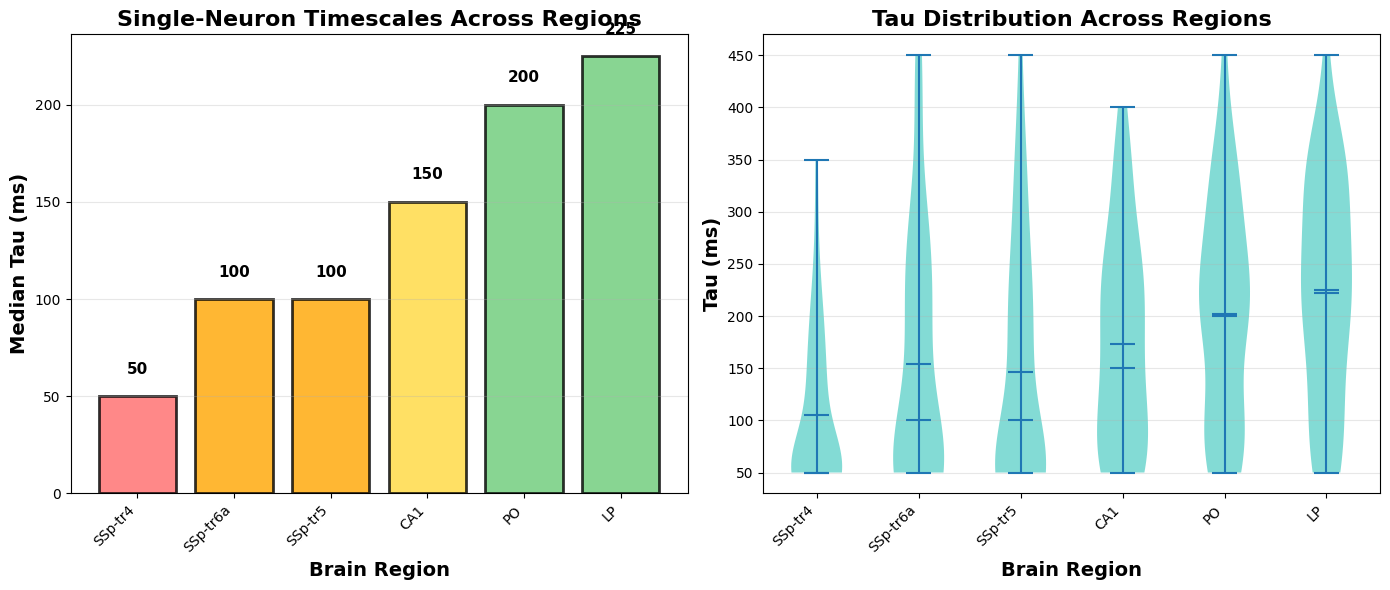

Plots created!


In [17]:
# =============================================================================
# VISUALIZATION
# =============================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT 1: Bar Chart
ax = axes[0]

regions = list(region_tau_relaxed.keys())
medians = [region_tau_relaxed[r]['median'] for r in regions]

# Sort by median
sorted_idx = np.argsort(medians)
regions_sorted = [regions[i] for i in sorted_idx]
medians_sorted = [medians[i] for i in sorted_idx]

# Colors
colors = []
for med in medians_sorted:
    if med < 75:
        colors.append('#FF6B6B')  # Red: Very fast
    elif med < 125:
        colors.append('#FFA500')  # Orange: Fast
    elif med < 175:
        colors.append('#FFD93D')  # Yellow: Medium
    else:
        colors.append('#6BCB77')  # Green: Slow

bars = ax.bar(regions_sorted, medians_sorted, color=colors,
              alpha=0.8, edgecolor='black', linewidth=2)

ax.set_ylabel('Median Tau (ms)', fontsize=14, fontweight='bold')
ax.set_xlabel('Brain Region', fontsize=14, fontweight='bold')
ax.set_title('Single-Neuron Timescales Across Regions',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add values on top of bars
for bar, val in zip(bars, medians_sorted):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{val:.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# PLOT 2: Violin Plot
ax = axes[1]

data_for_violin = [region_tau_relaxed[r]['all_taus'] for r in regions_sorted]

parts = ax.violinplot(data_for_violin, positions=range(len(regions_sorted)),
                      showmeans=True, showmedians=True)

for pc in parts['bodies']:
    pc.set_facecolor('#4ECDC4')
    pc.set_alpha(0.7)

ax.set_xticks(range(len(regions_sorted)))
ax.set_xticklabels(regions_sorted, rotation=45, ha='right')
ax.set_ylabel('Tau (ms)', fontsize=14, fontweight='bold')
ax.set_xlabel('Brain Region', fontsize=14, fontweight='bold')
ax.set_title('Tau Distribution Across Regions',
             fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Plots created!")